# NN from Scratch


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)


## 1) Caricamento e split (train/dev)

In [ ]:
data = pd.read_csv("train.csv", skiprows=1).to_numpy()
np.random.shuffle(data)

m, n = data.shape
# Split the data into training, development, and test sets (80% train, 10% dev, 10% test)
dev_size = int(0.1 * m)
test_size = int(0.1 * m)


data_dev = data[:dev_size].T #Traspone matrice per poi Z = W @ X + b
Y_dev = data_dev[0].astype(int) #label
X_dev = data_dev[1:n] / 255.0 #pixel normalizzati

data_train = data[dev_size + test_size:].T #split train
Y_train = data_train[0].astype(int)
X_train = data_train[1:n] / 255.0

data_test = data[dev_size:dev_size + test_size].T #split test
Y_test = data_test[0].astype(int)
X_test = data_test[1:n] / 255.0

print("X_train:", X_train.shape, "Y_train:", Y_train.shape)
print("X_dev:", X_dev.shape, "Y_dev:", Y_dev.shape)
print("X_test:", X_test.shape, "Y_test:", Y_test.shape)

X_train: (784, 33601) Y_train: (33601,)
X_dev: (784, 4199) Y_dev: (4199,)
X_test: (784, 4199) Y_test: (4199,)


## 2) Utility

In [3]:
def one_hot(Y, num_classes=10):
    Y = Y.astype(int)
    oh = np.zeros((num_classes, Y.size))
    oh[Y, np.arange(Y.size)] = 1
    return oh

def accuracy(pred, Y):
    return np.mean(pred == Y)

def softmax(Z):
    Z = Z - np.max(Z, axis=0, keepdims=True)  # stabilità numerica
    expZ = np.exp(Z)
    return expZ / np.sum(expZ, axis=0, keepdims=True)

def cross_entropy_loss(A2, Y_onehot, eps=1e-12):
    A2 = np.clip(A2, eps, 1 - eps)
    return -np.mean(np.sum(Y_onehot * np.log(A2), axis=0))


## 3) Attivazioni: ReLU e Sigmoid

In [4]:
def relu(Z):
    return np.maximum(0, Z)

def drelu(Z):
    return (Z > 0).astype(float)

def sigmoid(Z):
    Z = np.clip(Z, -500, 500)
    return 1 / (1 + np.exp(-Z))

def dsigmoid(A):
    return A * (1 - A)


## 4) Rete multilayer (forward/backward)
Architettura: `layer_sizes` es. `[784, 64, 10]` oppure `[784, 128, 64, 10]`.

In [5]:
def init_params(layer_sizes):
    params = {}
    for l in range(1, len(layer_sizes)):
        fan_in = layer_sizes[l-1]
        fan_out = layer_sizes[l]
        scale = np.sqrt(2.0 / fan_in) 
        params[f"W{l}"] = np.random.randn(fan_out, fan_in) * scale
        params[f"b{l}"] = np.zeros((fan_out, 1))
    return params

def forward(params, X, activation="relu"):
    caches = []
    A = X
    L = len(params) // 2

    for l in range(1, L):
        W, b = params[f"W{l}"], params[f"b{l}"]
        Z = W @ A + b
        if activation == "relu":
            A_next = relu(Z)
        elif activation == "sigmoid":
            A_next = sigmoid(Z)
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")
        caches.append((A, Z, W, b, A_next))
        A = A_next

    W, b = params[f"W{L}"], params[f"b{L}"]
    ZL = W @ A + b
    AL = softmax(ZL)
    caches.append((A, ZL, W, b, AL))
    return AL, caches

def backward(AL, caches, Y, activation="relu"):
    grads = {}
    L = len(caches)
    m = Y.size
    Y_oh = one_hot(Y, num_classes=AL.shape[0])

    A_prev, ZL, WL, bL, _ = caches[-1]
    dZ = AL - Y_oh
    grads[f"dW{L}"] = (1/m) * (dZ @ A_prev.T)
    grads[f"db{L}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
    dA_prev = WL.T @ dZ

    for l in reversed(range(1, L)):
        A_prev, Z, W, b, A = caches[l-1]
        if activation == "relu":
            dZ = dA_prev * drelu(Z)
        elif activation == "sigmoid":
            dZ = dA_prev * dsigmoid(A)
        else:
            raise ValueError("activation must be 'relu' or 'sigmoid'")
        grads[f"dW{l}"] = (1/m) * (dZ @ A_prev.T)
        grads[f"db{l}"] = (1/m) * np.sum(dZ, axis=1, keepdims=True)
        dA_prev = W.T @ dZ

    return grads

def update(params, grads, lr):
    L = len(params) // 2
    for l in range(1, L+1):
        params[f"W{l}"] -= lr * grads[f"dW{l}"]
        params[f"b{l}"] -= lr * grads[f"db{l}"]
    return params

def predict(params, X, activation="relu"):
    AL, _ = forward(params, X, activation=activation)
    return np.argmax(AL, axis=0)


## 5) Training (snello) + history

In [6]:
def train_model(X_train, Y_train, X_dev, Y_dev, layer_sizes, activation="relu",
                lr=0.1, iterations=100, log_every=10):
    params = init_params(layer_sizes)
    history = {"iter": [], "train_loss": [], "dev_acc": []}

    for i in range(iterations + 1):
        AL, caches = forward(params, X_train, activation=activation)
        grads = backward(AL, caches, Y_train, activation=activation)
        params = update(params, grads, lr)

        if i % log_every == 0:
            loss = cross_entropy_loss(AL, one_hot(Y_train, AL.shape[0]))
            dev_acc = accuracy(predict(params, X_dev, activation=activation), Y_dev)
            history["iter"].append(i)
            history["train_loss"].append(loss)
            history["dev_acc"].append(dev_acc)
            print(f"iter={i:4d} | loss={loss:.4f} | dev_acc={dev_acc:.4f}")

    return params, history


## 6) Esperimenti *pochi* (facili da cambiare)
Griglia **minimal**: 2 architetture × 2 LR × 2 attivazioni = 8 run.
Puoi ridurre ancora se vuoi.

In [7]:
architectures = [
    [784, 64, 10],        
    [784, 128, 64, 10],  
]
learning_rates = [0.05, 0.1]
activations = ["relu", "sigmoid"]

iterations = 120
log_every = 20

runs = []
for act in activations:
    for arch in architectures:
        for lr in learning_rates:
            print("\n" + "-"*70)
            print(f"activation={act} | arch={arch} | lr={lr}")
            params, hist = train_model(
                X_train, Y_train, X_dev, Y_dev,
                layer_sizes=arch, activation=act,
                lr=lr, iterations=iterations, log_every=log_every
            )
            runs.append({"activation": act, "arch": arch, "lr": lr, "params": params, "history": hist})

print("\nRISULTATI FINALI (dev_acc finale):")
for r in sorted(runs, key=lambda x: x["history"]["dev_acc"][-1], reverse=True):
    print(f"{r['history']['dev_acc'][-1]:.4f} | {r['activation']:<7} | {r['arch']} | lr={r['lr']}")



----------------------------------------------------------------------
activation=relu | arch=[784, 64, 10] | lr=0.05
iter=   0 | loss=2.4769 | dev_acc=0.0876
iter=  20 | loss=1.5997 | dev_acc=0.6530
iter=  40 | loss=1.1201 | dev_acc=0.7749
iter=  60 | loss=0.8701 | dev_acc=0.8157
iter=  80 | loss=0.7312 | dev_acc=0.8316
iter= 100 | loss=0.6443 | dev_acc=0.8433
iter= 120 | loss=0.5847 | dev_acc=0.8552

----------------------------------------------------------------------
activation=relu | arch=[784, 64, 10] | lr=0.1
iter=   0 | loss=2.4006 | dev_acc=0.1331
iter=  20 | loss=1.3026 | dev_acc=0.7421
iter=  40 | loss=0.8028 | dev_acc=0.8254
iter=  60 | loss=0.6158 | dev_acc=0.8523
iter=  80 | loss=0.5256 | dev_acc=0.8645
iter= 100 | loss=0.4723 | dev_acc=0.8731
iter= 120 | loss=0.4368 | dev_acc=0.8804

----------------------------------------------------------------------
activation=relu | arch=[784, 128, 64, 10] | lr=0.05
iter=   0 | loss=2.5032 | dev_acc=0.1143
iter=  20 | loss=1.7015 

## 7) Plot convergenza

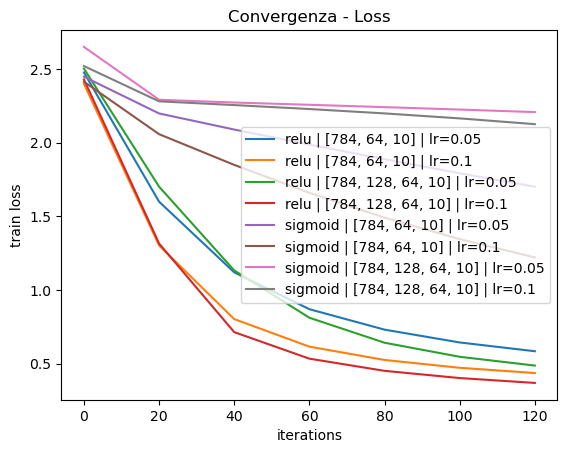

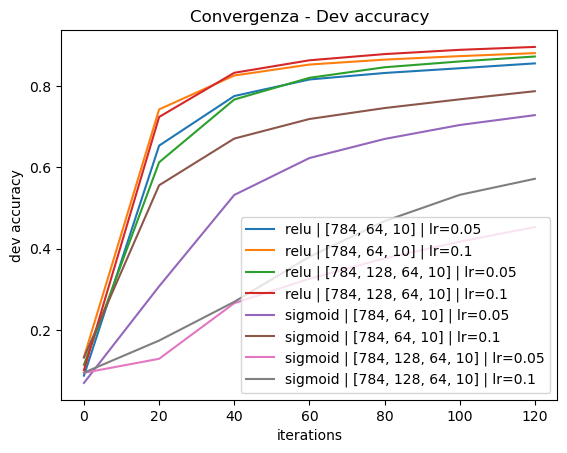

In [8]:
plt.figure()
for r in runs:
    h = r["history"]
    label = f"{r['activation']} | {r['arch']} | lr={r['lr']}"
    plt.plot(h["iter"], h["train_loss"], label=label)
plt.xlabel("iterations")
plt.ylabel("train loss")
plt.title("Convergenza - Loss")
plt.legend()
plt.show()

plt.figure()
for r in runs:
    h = r["history"]
    label = f"{r['activation']} | {r['arch']} | lr={r['lr']}"
    plt.plot(h["iter"], h["dev_acc"], label=label)
plt.xlabel("iterations")
plt.ylabel("dev accuracy")
plt.title("Convergenza - Dev accuracy")
plt.legend()
plt.show()


BEST: relu [784, 128, 64, 10] lr= 0.1 dev_acc= 0.8956894498690164
TEST ACCURACY: 0.8921171707549417


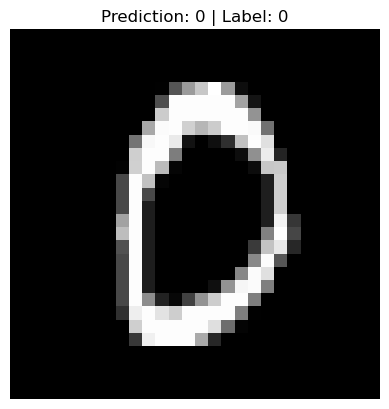

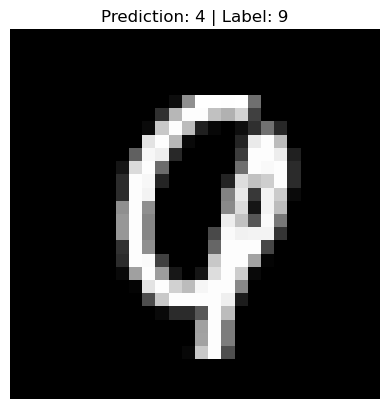

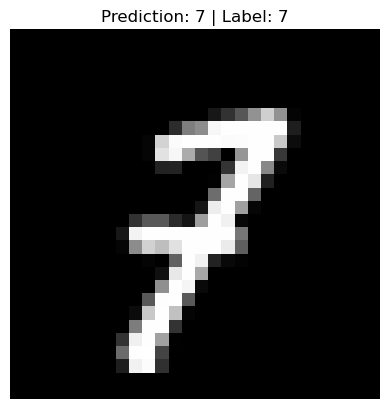

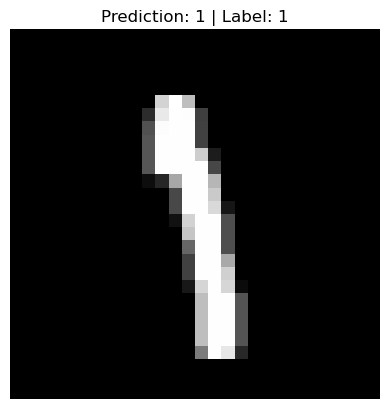

In [9]:
best = max(runs, key=lambda x: x["history"]["dev_acc"][-1])
best_params = best["params"]

print("BEST:", best["activation"], best["arch"], "lr=", best["lr"], "dev_acc=", best["history"]["dev_acc"][-1])

# Test Accuracy
test_acc = accuracy(
    predict(best_params, X_test, activation=best["activation"]),
    Y_test
)

print("TEST ACCURACY:", test_acc)

def show_prediction(index, params, activation="relu"):
    x = X_test[:, index:index+1]
    pred = predict(params, x, activation=activation)[0]
    label = Y_test[index]

    img = (x.reshape(28, 28) * 255.0)

    plt.figure()
    plt.imshow(img, cmap="gray", interpolation="nearest")
    plt.title(f"Prediction: {pred} | Label: {label}")
    plt.axis("off")
    plt.show()

for idx in [0, 1, 2, 3]:
    show_prediction(idx, best_params, activation=best["activation"])
